**Aprendizaje automático 1 - Politécnico Malvinas argentinas**

Clase 2 - Actividad integradora
Alumno: Enzo Ariel Melián

1️ Identificación de Tipos de Datos

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, LabelEncoder

# Carga del dataset
df = pd.DataFrame({ "ID": [1, 2, 3, 4, 5],
                    "Nombre": ["Juan", "María", "Pedro", "Ana", "Luis"],
                    "Edad": [32, -28, 40, 35, 50],
                    "Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
                    "Salario": [50000, 60000, None, 55000, 200000],
                    "Categoría": ["Junior", "Senior", "Senior", "Junior", "Manager"],
                    "Estado": ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"] }).copy()
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,-28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,NaN,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               5 non-null      int64  
 1   Nombre           5 non-null      object 
 2   Edad             5 non-null      int64  
 3   Nivel_Educativo  5 non-null      object 
 4   Salario          4 non-null      float64
 5   Categoría        5 non-null      object 
 6   Estado           5 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 412.0+ bytes
None


------
Se pueden identificar que el dataset es semiestructurado, ya que está organizado en filas y columnas pero sin llegar a ser estrictamente una base de datos relacional. Posee 6 columnas:

  1. ID: Es la identificación de cada registro, es tipo númerico(INT). Es importante no modificar los datos de esta columna a menos que sean nulos o no únicos.
    
  2. Nombre: Es el nombre de cada empleado, es tipo categórico(cadena o caracteres mixtos). En columnas Object es conveniente no hacer operaciones matematicas.
    
  3. Edad: Es la edad de cada empleado, es tipo númerico(INT). Esta columna debe tener valores mayores o igual a 18 y menores a 100.
        - 1 registro, posee un valor negativo.
        
  4. Nivel_Educativo: Es la formación acádemica de cada empleado, es tipo object(cadena o caracteres mixtos). Esta columna podría transformarse a valores ordinales (categorías con un orden lógico) para facilitar un análisis completo.
        - La columna se debe normalizar, y luego el orden recomendado para la ordinalidad es: Licenciatura, Ingenieria, y Doctorado.
        
  5. Salario: Es la remuneración de cada empleado, es tipo INT. Esta columna debe ser mayor a 0.
        - 1 registro, posee un valor nulo.
        
  6. Categoria: Es el nivel de experiencia que tiene cada uno, es tipo Object (cadena o caracteres mixtos). Esta columna podría transformarse a ordinal(categorías con un orden lógico).
        - La columna debe ser normalizada, y luego el orden recomendado para la ordinalidad es: Junior, Senior, Manager.
        
  7. Estado: Es una verificación si el empleado está en actividad o no, es tipo Object. Esta columna podría ser binaria, para así mejorar el rendimiento.
        - La columna debe ser normalizada, ya que 1 registro, no está normalizado.

----
2️ Limpieza de Datos

1. Detecta y corrige valores faltantes en las columnas necesarias.
2. Identifica y elimina valores atípicos en la columna “Salario”.
3. Corrige inconsistencias en los datos categóricos (ejemplo: "Licenciado" y "licenciado" deben ser tratados como el mismo valor).


In [21]:
#Correccion de registro nulo en Salario
df["Salario"] = df["Salario"].fillna(df["Salario"].median())

#Correcion de edad negativa
df["Edad"] = df["Edad"].abs()

#Normalización de datos categoricos
df["Nombre"] = df["Nombre"].str.strip().str.title()
df["Nivel_Educativo"] = df["Nivel_Educativo"].str.strip().str.title()
df["Categoría"] = df["Categoría"].str.strip().str.title()
df["Estado"] = df["Estado"].str.strip().str.lower()

#Eliminación de valores atipicos en la columna salario
Q1, Q3 = df["Salario"].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[~((df["Salario"] < (Q1 - 1.5 * IQR)) | (df["Salario"] > (Q3 + 1.5 * IQR)))]

df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,activo
1,2,María,28,Ingeniero,60000.0,Senior,activo
2,3,Pedro,40,Doctorado,57500.0,Senior,inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,activo


Los procesos realizados en la limpieza de datos consistieron en:
1. Correción del registro nulo en salario, el registro (2) de la columna "Salario" que poseía un valor NaN ahora posee un valor promedio entre los demás salarios.
2. Correción de un registro (1) con edad negativa en la columna "Edad", el valor anterior era -28 y ahora es 28
3. Correción de las columnas categoricas "Nombre", "Nivel_educativo", "Categoría" y "Estado" haciendo que todos los valores tengan un formato de titulo, y sin espacios en blanco.
4. Eliminación de valores atipicos en la columna "Salario", se elimino el registro (4) perteneciente al manager que poseía un salario 3 veces más alto a comparación de los demás empleados.
    

---

3️ Transformación de Datos

1. Convierte las variables categóricas en numéricas utilizando codificación ordinal o One-Hot Encoding.
2. Aplica normalización al salario para facilitar comparaciones.
3. Crea una nueva variable “Años hasta jubilación” suponiendo que la edad de retiro es 65 años.

In [22]:
#Creo una copia del dataset, para hacer la transformación sin problemas
df = df.copy(deep=True).reset_index(drop=True)

#Codificacion ordinal para las columnas Nivel_Educativo, y Categoría.
encoder_ordinal_nivel = OrdinalEncoder(categories=[["Licenciado", "Ingeniero", "Doctorado"]])
df["Nivel_Cod"] = encoder_ordinal_nivel.fit_transform(df[["Nivel_Educativo"]]).ravel()

encoder_ordinal_cat = OrdinalEncoder(categories=[["Junior", "Senior", "Manager"]])
df["Categoría_Cod"] = encoder_ordinal_cat.fit_transform(df[["Categoría"]]).ravel()

#Codificacion map para la columna binaria Estado
df.loc[:, "Estado"] = df["Estado"].map({
    "activo": 1,
    "inactivo": 0
})

#Normalizacion del salario
scaler = MinMaxScaler()
df["Salario_Normalizado"] = scaler.fit_transform(df[["Salario"]])

#Creacion nueva columna "años hasta jubilacion"
df["Años_Hasta_Jubilación"] = 65 - df["Edad"]

df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod,Categoría_Cod,Salario_Normalizado,Años_Hasta_Jubilación
0,1,Juan,32,Licenciado,50000.0,Junior,1,0.0,0.0,0.00,33
1,2,María,28,Ingeniero,60000.0,Senior,1,1.0,1.0,1.00,37
2,3,Pedro,40,Doctorado,57500.0,Senior,0,2.0,1.0,0.75,25
3,4,Ana,35,Licenciado,55000.0,Junior,1,0.0,0.0,0.50,30


Los procesos realizados en esta etapa consistieron en:
1.

---
4️ . Análisis Exploratorio con LLM

1. Generar un resumen de los datos.
2. Explicar cómo manejar valores faltantes.
3. Sugerir formas de visualizar los datos.


### Resumen de los datos

In [23]:
print('Resumen estadístico de las columnas numéricas:')
display(df.describe())

Resumen estadístico de las columnas numéricas:


,ID,Edad,Salario,Nivel_Cod,Categoría_Cod,Salario_Normalizado,Años_Hasta_Jubilación
count,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000
mean,2.500000,33.750000,55625.000000,0.750000,0.50000,0.562500,31.250000
std,1.290994,5.057997,4269.562819,0.957427,0.57735,0.426956,5.057997
min,1.000000,28.000000,50000.000000,0.000000,0.00000,0.000000,25.000000
25%,1.750000,31.000000,53750.000000,0.000000,0.00000,0.375000,28.750000
50%,2.500000,33.500000,56250.000000,0.500000,0.50000,0.625000,31.500000
75%,3.250000,36.250000,58125.000000,1.250000,1.00000,0.812500,34.000000
max,4.000000,40.000000,60000.000000,2.000000,1.00000,1.000000,37.000000


En el resumen se puede apreciar:
- El conteo de cada registro por columna. Notando que todas las columnas tienen el mismo valor, significa que no hay ningún valor nulo.
- El promedio, que en variables como la edad y salario podemos sacar información relevante.
- Valores minimos y maximos (min y max) que nos da información importantes sobre los limites inferiores y superiores presentes en cada columna.
- Desviación estandar, que es una medida estadística que cuantifica la dispersión de un conjunto de datos respecto a su media.
- Cuartiles, 25% (Q1), 50% (Q2 o media) y 75% (Q3) que muestra que cantidad, son medidas estadísticas que dividen un conjunto de datos ordenados en cuatro partes iguales.

In [24]:
print('\nInformación general del DataFrame (tipos de datos, valores no nulos):')
df.info()


Información general del DataFrame (tipos de datos, valores no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4 non-null      int64  
 1   Nombre                 4 non-null      object 
 2   Edad                   4 non-null      int64  
 3   Nivel_Educativo        4 non-null      object 
 4   Salario                4 non-null      float64
 5   Categoría              4 non-null      object 
 6   Estado                 4 non-null      object 
 7   Nivel_Cod              4 non-null      float64
 8   Categoría_Cod          4 non-null      float64
 9   Salario_Normalizado    4 non-null      float64
 10  Años_Hasta_Jubilación  4 non-null      int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 484.0+ bytes




---


Este histograma (gráfico de distribución) de la edad es fundamental para comprender la composición de nuestro conjunto de datos en términos de la edad de los empleados. Su utilidad y cómo interpretarlo se resumen en:

*   **Identificar el Rango de Edades:** Te permite ver rápidamente cuál es la edad mínima y máxima de los empleados en el dataset.
*   **Visualizar la Concentración de Edades:** Las barras más altas indican los rangos de edad donde hay una mayor cantidad de empleados.
*   **Detectar la Forma de la Distribución:** Puedes observar si la distribución de edades es simétrica (pareja a ambos lados de la media), sesgada a la izquierda (más empleados jóvenes) o sesgada a la derecha (más empleados mayores).
*   **Identificar Anomalías o Atípicos:** Si hay barras muy pequeñas o aisladas en los extremos, podría indicar la presencia de pocos empleados muy jóvenes o muy mayores.
*   **Tomar Decisiones Basadas en la Demografía:** una distribución con muchos empleados jóvenes podría sugerir la necesidad de programas de desarrollo y crecimiento, mientras que una población de empleados más madura podría requerir planes de sucesión o beneficios de jubilación.

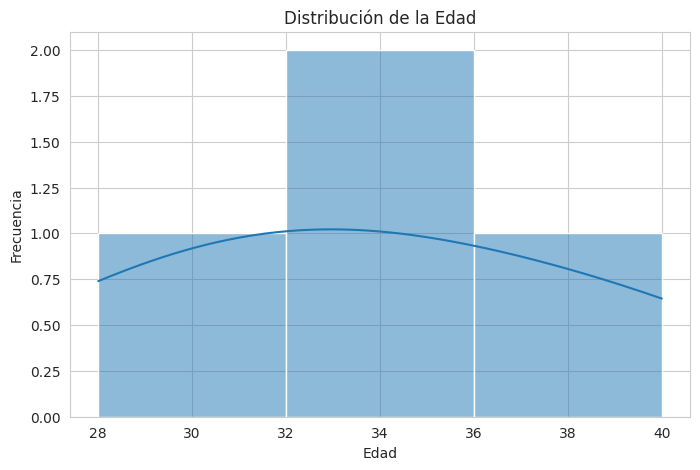

In [25]:
# Configurar el estilo de los gráficos
sns.set_style("whitegrid")

# Gráfico de distribución de la Edad
plt.figure(figsize=(8, 5))
sns.histplot(df['Edad'], kde=True)
plt.title('Distribución de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

Podemos identificar entonces que:
- Los rangos de edad van desde el 28 hasta el 40.
- La barra grande presente entre 32 y 36 marcan que hay más empleados en ese rango de edad.



---


El siguiente gráfico de barras de salario mediano por categoría es útil para:

*   **Comparar Salarios entre Categorías:** Permite visualizar rápidamente cómo el salario mediano difiere entre las distintas categorías de empleados (Junior, Senior, Manager).
*   **Identificar Diferencias Salariales:** Ayuda a entender las posibles brechas salariales entre las categorías, lo cual puede ser un punto de partida para análisis de equidad o estructuras de compensación.
*   **Soporte para Gestión de Talento:** Puede informar decisiones sobre promociones, rangos salariales y desarrollo de carrera, al mostrar el valor salarial asociado a cada nivel de experiencia o responsabilidad.

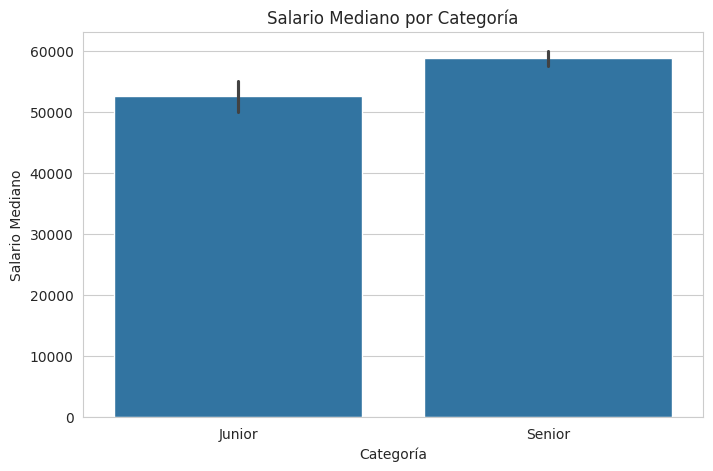

In [26]:
# Gráfico de barras del Salario por Categoría
plt.figure(figsize=(8, 5))
sns.barplot(x='Categoría', y='Salario', data=df, estimator=np.median)
plt.title('Salario Mediano por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Salario Mediano')
plt.show()

De este gráfico podemos identificar:
- Que la categoría de Senior (que hace muchas veces referencia a gente experimentada en un área) es promedio suele tener un sueldo más alto que un junior.




---

En el siguiente gráfico de barras que relaciona el nivel educativo y la categoria de cada empleado es muy útil para:

*   **Observar la Distribución:** Permite ver cómo se distribuyen las diferentes categorías de empleados (Junior, Senior, Manager) dentro de cada nivel educativo (Licenciado, Ingeniero, Doctorado).
*   **Identificar Tendencias y Concentraciones:** Podemos identificar si un nivel educativo particular está sobrerrepresentado o subrepresentado en una categoría específica. Por ejemplo, si todos los 'Doctorado' son 'Manager', o si hay más 'Ingenieros' en la categoría 'Senior'.
*   **Informar Estrategias de Contratación y Desarrollo:** Esta visualización puede ayudar a entender si los requisitos educativos se alinean con las categorías de puestos, y a informar decisiones sobre la trayectoria profesional o programas de capacitación.

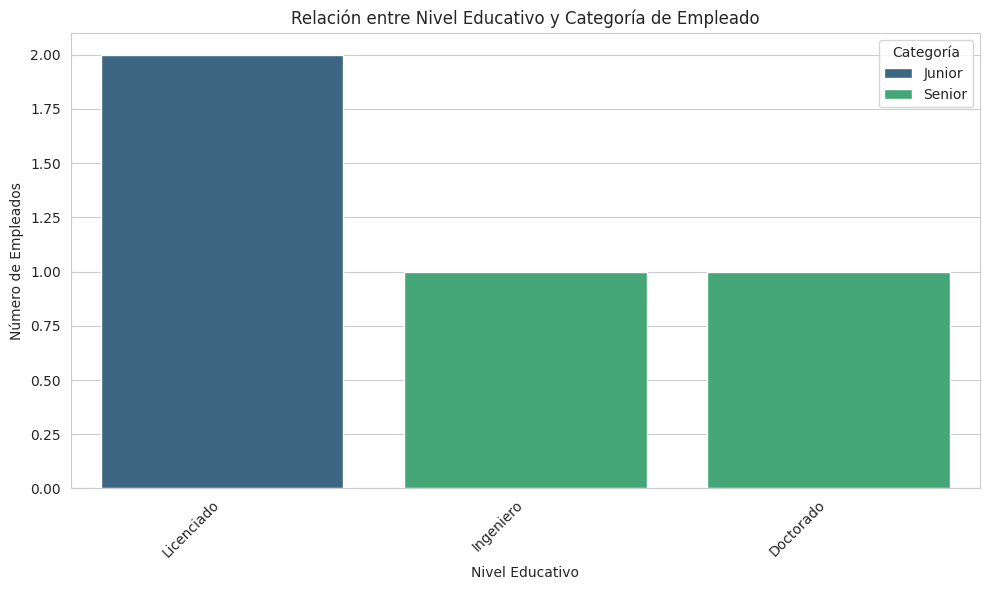

In [27]:
# Gráfico de barras agrupado para Nivel_Educativo vs Categoría
plt.figure(figsize=(10, 6))
sns.countplot(x='Nivel_Educativo', hue='Categoría', data=df, palette='viridis')
plt.title('Relación entre Nivel Educativo y Categoría de Empleado')
plt.xlabel('Nivel Educativo')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría')
plt.tight_layout()
plt.show()

Del anterior gráfico podemos concluir que:
- Hay más empleados con licenciaturas, y que tienden a ser Junior. Mientras que los ingenieros y doctorados tienen la categoría de Senior.
- Sumando las interpretaciones de este gráfico y el de Salario medio por categoría, podemos concluir que los licenciados ganan menos respecto a los ingenieros y doctores porque su nivel de categoría es diferntes (los primeros siendo junior, y los segundo siendo senior)



---

Preguntas que le realice a Gemini.

**1. ¿Tengo un dataset con sueldos y edades, ¿cómo puedo detectar y eliminar outliers en Python?**

  - Su respuesta resumida fue, utilizando el método del rango intercuartilico. Usado en la columna Salario para localizar y borrar los valores que no siguieran una distribución normal.
    O bien el método de puntuación Z, que es útil cuando los datos siguen una distribución aproximadamente normal, midiendo cuántas desviaciones estándar está un punto de datos de la media.
  - Como consideraciones puso que tenga en cuenta el contexto del negocio, la imputación y la visualización previa a eliminar los outliners.


**2. ¿Que gráficos en conveniente realizar en mis gráficos?**

  - En resumidas cuenta me propuso 4 diferentes. Que serían:
    - Un gráfico de relación de distribución de edad
    - Un gráfico de relación edad-salario.
    - Un gráfico de salario mediano por categoría.
    - Un gráfico de los años hasta la jubilación.

    De estos gráficos, solo utilice 2 el de salario mediano por categoría y el de distribución de de edad. Para luego agregar el de relación entre nivel educativo y categoría de empleado. Siento que estos 3 son más que suficientes para visualizaciones completas y efectivas que respondan a preguntas concretas.

    No utilice el de edad-salario porque tomaba en cuenta la edad de cada trabajador y no de su tiempo en la empresa, donde si habría una correlación más fuerte y justificada.

    No utilice tampoco el de años hasta la jubilación, porque si bien es la edad máxima hasta donde trabajaran los empleados, de por sí no es una variable importante a fines de corto o mediano plazo.

**3. ¿Que metodos de transformación de datos son convenientes en columnas categoricas, y cuales en numericas?**

  Resumiendo su respuesta.
 - Para columnas categoricas:
    - Codificación ordinal. (que fue utilizada en las columnas de Nivel_Educativo y Categoria)
    - One-hot encoding.
    - Label encoding

  - Para columnas numericas:
    - Normalización. (utilizada en Edad. Para evitar edades negativas y menores a 18, o mayores a 65).
    - Estandarización.
    - Transformación de raíz cuadrada/cúbica.

  De las recomendaciones de la IA si bien no aplique todas, porque para el ejercicio no hacía falta, denoto que su importancia es bastante especifica. Para un analisis de datos más completo tambien se necesitaría un dataset más amplio, y objetivos más abarcativos.